# ■ 머신러닝 컴페티션


### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.


데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data


## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

- [x] (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

- [x] (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

- [x] (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

- [x] (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

- [x] (5점) validation score 적절하게 출력 (300자 이내, 주석 서술하기)


## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶ 둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)


# 전체 코드 하단 작성

    ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터


## Pycaret - 최적 모델 찾기


In [2]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df["churn"])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.
# 내림차순으로 Ada Boost, CatBoost, lightgbm, gradient boost, random forest

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0960
catboost,CatBoost Classifier,0.8584,0.8637,0.4681,0.7432,0.5732,0.4937,0.5133,1.1650
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.4070
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.2720
rf,Random Forest Classifier,0.8580,0.8440,0.4401,0.7621,0.5571,0.4800,0.5060,0.2300
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0550
et,Extra Trees Classifier,0.8550,0.8419,0.4322,0.7525,0.5478,0.4691,0.4952,0.1630
dt,Decision Tree Classifier,0.7848,0.6768,0.4943,0.4733,0.4832,0.3475,0.3479,0.0140
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0070
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0070


## EDA


In [3]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df.info()       # 결측치 및 데이터타입 확인
                # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
df["country"].value_counts()            # France, Germany, Spain
df["gender"].value_counts()             # Male, Female
df["tenure"].value_counts()             # 0~10
df["products_number"].value_counts()    # 1~4
df["credit_card"].value_counts()        # 1, 0
df["active_member"].value_counts()      # 1, 0

active_member
1    5151
0    4849
Name: count, dtype: int64

### Preprocessing

LabelEncoder 사용하여 범주형인 'country', 'gender' 값을 수치형으로 변환  
모든 데이터를 계산 가능한 형태로 변환함으로서 상관관계 파악이 더 쉬워짐


In [6]:
# 전처리: 범주형 -> 수치형 값으로 변환

from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_gender = LabelEncoder()
df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,2,1,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,0,1,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,1,0,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,0,1,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,0,1,27,2,134603.88,1,1,1,71725.73,0


### Visualization


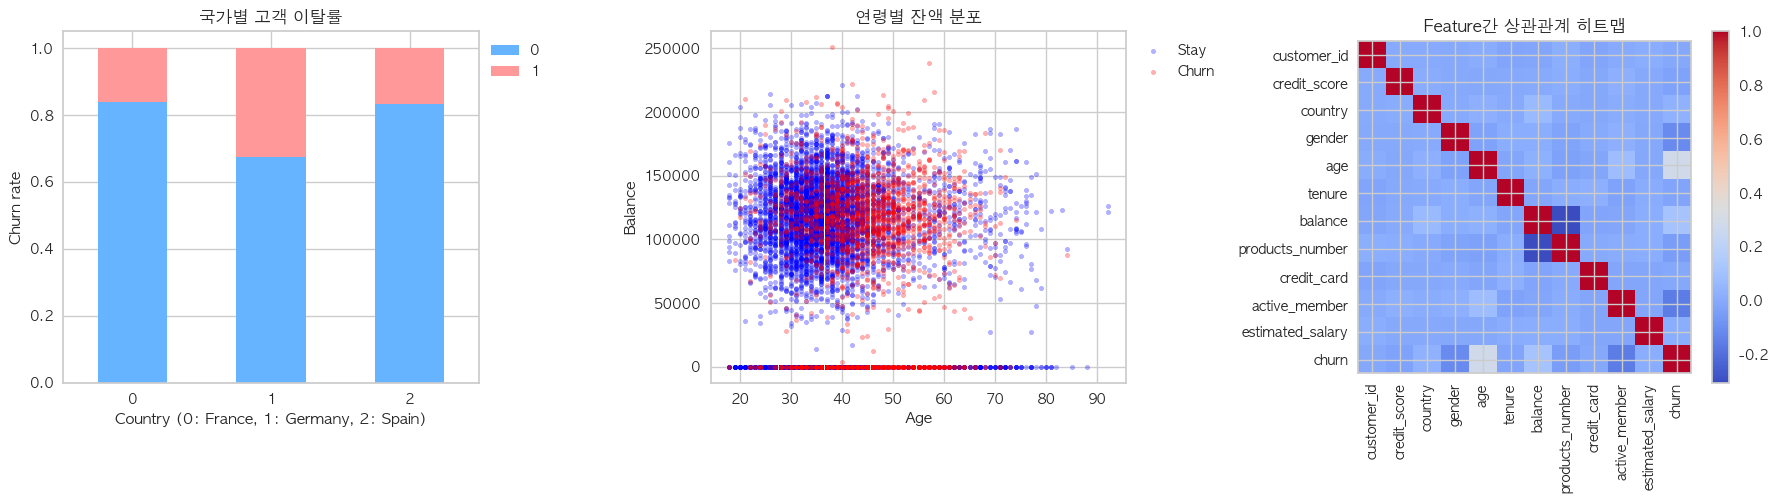

In [7]:
import matplotlib.pyplot as plt

plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(18, 5))

# # --- 1. 국가별 이탈률 비교 ---
plt.subplot(1, 3, 1)
churn_by_country = df.groupby(['country', 'churn']).size().unstack()
churn_by_country_pct = churn_by_country.div(churn_by_country.sum(axis=1), axis=0)
churn_by_country_pct.plot(kind='bar', stacked=True, color=['#66b3ff', '#ff9999'], ax=plt.gca())
plt.title('국가별 고객 이탈률')
plt.xlabel('Country (0: France, 1: Germany, 2: Spain)')
plt.ylabel('Churn rate')
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# # --- 2. 연령별 잔액 분포 ---
plt.subplot(1, 3, 2)
# 남아있는 고객은 파란색, 이탈 고객은 빨간색
stay = df[df['churn'] == 0]
churn = df[df['churn'] == 1]
plt.scatter(stay['age'], stay['balance'], color='blue', alpha=0.3, label='Stay', s=10)
plt.scatter(churn['age'], churn['balance'], color='red', alpha=0.3, label='Churn', s=10)
plt.title('연령별 잔액 분포')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# # --- 3. 상관관계 히트맵 ---
plt.subplot(1, 3, 3)
corr = df.corr()
im = plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature간 상관관계 히트맵')

plt.tight_layout()
plt.show()

### Description & Insight

1. 국가별 고객 이탈율  
   프랑스, 스페인에 비해 _독일_ 고객의 이탈률이 현저히 높음.

   > 독일 고객의 서비스 만족도 점검 필요

2. 연령별 잔액 분포  
   파란색(유지) 점들은 20~40대 사이에 많이 분포되어 있는 반면, 빨간색(이탈) 점들은 _40~60대_ 사이에 많이 분포되어 있음  
   잔액보다는 *나이*가 이탈율에 더 영향을 미치는 것으로 보임  
   (잔액이 현저하게 높은데 이탈한 고객도 있음)  
   청년에서 중장년이 되어갈수록(은퇴 자산 관리 시점) 고객들이 더 나은 조건을 찾아 다른 은행으로 옮겨갈 위험이 큰 것으로 보임

   > 40~60대의 우량 고객을 위한 은퇴 설계/자산 관리 서비스 강화로 락인 효과 노리는 것이 필요해 보임

3. Feature간 상관관계 히트맵  
   churn(이탈여부)와 가장 관련도가 높은 피처는 *age(나이)*이고, 양의 상관관계임  
   *products_number(상품 수)*도 churn과 관련도가 높은데, 음의 상관관계임 (= 이용 상품 수가 많을수록 덜 떠난다.)  
   credit score(신용점수)나 salary(급여), tenure(이용 기간) 등등...보다도 나이와 상품 수가 이탈 방지를 위한 더 주요한 지표인 것
   > 이탈 방지 모델을 만들 때 '나이' 변수 고려해야 하며, 고객당 가입 상품 수를 늘리는 크로스 셀링 전략이 이탈률을 낮추는 데 유효할 것으로 보임

세 그래프를 종합적으로 보았을 때 가장 위험한 고객군: **독일에 거주하는 40~60대, 이용하는 상품 수가 적은 고객**  
이탈 예측 시 집중해야 함.


## Feature Selection, Hold Out & Scaling


EDA 결과를 바탕으로 타겟('churn')과 관련성 높은 피처 'age', 'products_number', 'country', 'balance'를 선정하였음.  
('balance': 히트맵에서 진한 파랑으로 나왔기 때문에 포함하였음.)


In [8]:
# X, y
# X = df.drop('churn', axis=1)
X = df[['age', 'products_number', 'country', 'balance']]
y = df['churn']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

## Optuna

위에서 Pycaret으로 확인했던 상위 4개 모델 AdaBoostClassifier, GradientBoostingClassifier, LGBMClassifier, RandomForestClassifier 사용


In [9]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기

import optuna
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

# 1. AdaBoost
def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 2. LightGBM 
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }
    model = LGBMClassifier(**params, random_state=42, verbosity=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 3. Gradient Boosting
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 4. Random Forest 
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# --- 각 모델마다 옵튜나 실행 ---

# AdaBoost
study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=20)

# LightGBM
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=20)

# Gradient Boosting
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=20)

# Random Forest
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)


[I 2026-04-09 16:17:37,897] A new study created in memory with name: no-name-9d740b06-ecc8-416a-b2d8-fa5349b9e049
[I 2026-04-09 16:17:38,150] Trial 0 finished with value: 0.44673539518900346 and parameters: {'n_estimators': 65, 'learning_rate': 0.15039427195984387}. Best is trial 0 with value: 0.44673539518900346.
[I 2026-04-09 16:17:38,959] Trial 1 finished with value: 0.2489451476793249 and parameters: {'n_estimators': 236, 'learning_rate': 0.02279346250749438}. Best is trial 0 with value: 0.44673539518900346.
[I 2026-04-09 16:17:39,172] Trial 2 finished with value: 0.23126338329764454 and parameters: {'n_estimators': 61, 'learning_rate': 0.06822504990775646}. Best is trial 0 with value: 0.44673539518900346.
[I 2026-04-09 16:17:39,725] Trial 3 finished with value: 0.2489451476793249 and parameters: {'n_estimators': 162, 'learning_rate': 0.031122082790491334}. Best is trial 0 with value: 0.44673539518900346.
[I 2026-04-09 16:17:40,206] Trial 4 finished with value: 0.16179775280898875 

In [10]:
# 옵튜나로 찾은 각 모델의 최적 하이퍼 파라미터로 모델 객체 정의
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbosity=-1)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

# 모델 학습
ada.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
gbc.fit(X_train, y_train)
rf.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
models = [
    ('AdaBoost', ada),
    ('LightGBM', lgbm),
    ('GradientBoost', gbc),
    ('RandomForest', rf)
]

print("--- 하이퍼파라미터 튜닝 후 결과 ---")
for name, model in models:
    pred = model.predict(X_valid)
    score = f1_score(y_valid, pred)
    print(f"[{name}] F1 score: {score:.4f}")

--- 하이퍼파라미터 튜닝 후 결과 ---
[AdaBoost] F1 score: 0.5509
[LightGBM] F1 score: 0.5569
[GradientBoost] F1 score: 0.5620
[RandomForest] F1 score: 0.5602


## SHAP Value


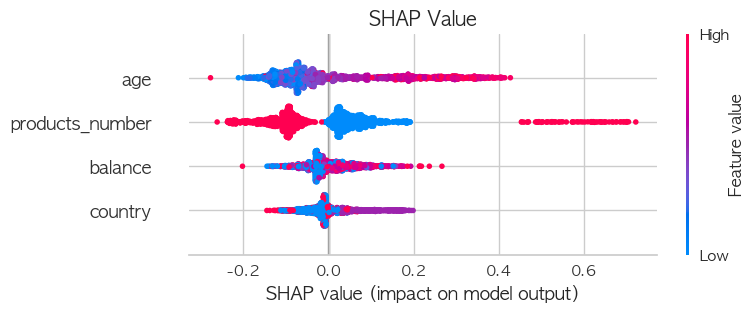

In [11]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

import shap

explainer = shap.TreeExplainer(rf)              # Random Forest 
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()

### Description & Insight

> SHAP value가 오른쪽으로 쏠리면 이탈률 높은 것으로 해석

1. age:  
   높을수록 이탈률이 높다. 가장 중요한 지표.

2. products_number:  
   상품 수가 적을수록 이탈률이 높고, 상품 수가 많으면 이탈률이 낮음.  
   단, 더 빨간(피처 밸류 높은) 점들이 오른쪽에 분포되어 있는 양상을 보아, 상품 3~4개 가입자가 오히려 특이 케이스로 이탈하는 경향이 있음.

3. balance:  
   잔액이 높을수록 이탈하는 경향 있음. (우량 고객의 이탈)
4. country:  
   국가별로 임의의 숫자를 부여한 것이므로 연속적 수치로 해석하는 것이 부적절함.  
   다만 보라색(독일) 고객의 이탈률이 높은 것을 확인할 수 있음.

<br/>

> 어떤 마케팅 전략을 취해볼 수 있을까...

1. 시니어 케어 서비스 강화 (age 대응):  
   40~60세 중장년층 고객을 위한 전담 자산 관리 서비스나 상속/연금 특화 상품을 출시

2. 크로스 셀링(Cross-selling) 유도 (products_number 대응):  
   상품을 1개만 이용 중인 고객에게 두 번째 상품(적금, 보험, 신용카드 등) 가입 유도 - 금리 혜택을 제공하여  
   락인 효과 노림

3. 우량 고객 및 독일 집중 마케팅 (balance & country 대응):  
   '독일의 고액 자산가'가 이탈하지 않게 VIP 우대 또는 지역 특화 금융 관리 도입


## Stacking


In [12]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나), F1/Accuracy score를 출력

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 전방 모델 리스트
# 앞서 선언한 네 가지 모델 객체 사용
est_model_list = [
    ('ada', ada),
    ('lgbm', lgbm),
    ('gbc', gbc),
    ('rf', rf)
]

# Stacking 모델 설정
stack = StackingClassifier(
    estimators = est_model_list,            # 전방 모델
    final_estimator = LogisticRegression(), # 후방 모델
    cv = 5,                                 # cross validation (데이터 5등분)
    n_jobs = -1                             # 병렬 처리
)

#  모델 학습
stack.fit(X_train, y_train)

# 예측 및 F1 스코어 출력
pred = stack.predict(X_valid)
print("Stacking F1 Score:", f1_score(y_valid, pred))

Stacking F1 Score: 0.5523520485584219
